<a href="https://colab.research.google.com/github/Fatfara/sleep-predictor/blob/main/sleepQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
!git clone https://github.com/Fatfara/sleep-predictor.git

Cloning into 'sleep-predictor'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [76]:
df=pd.read_csv(f'/content/Health_Sleep_Statistics.csv')
df.head()

,User ID,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no
3,4,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no
4,5,22,f,8,23:30,07:00,10000,2800,high,medium,no,no


In [77]:
df.size

1200

In [78]:
df.columns.size

12

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   User ID                  100 non-null    int64 
 1   Age                      100 non-null    int64 
 2   Gender                   100 non-null    object
 3   Sleep Quality            100 non-null    int64 
 4   Bedtime                  100 non-null    object
 5   Wake-up Time             100 non-null    object
 6   Daily Steps              100 non-null    int64 
 7   Calories Burned          100 non-null    int64 
 8   Physical Activity Level  100 non-null    object
 9   Dietary Habits           100 non-null    object
 10  Sleep Disorders          100 non-null    object
 11  Medication Usage         100 non-null    object
dtypes: int64(5), object(7)
memory usage: 9.5+ KB


In [80]:
df.describe()

,User ID,Age,Sleep Quality,Daily Steps,Calories Burned
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,36.010000,7.000000,6830.000000,2421.00000
std,29.011492,8.454865,1.734964,2498.706736,281.06759
min,1.000000,22.000000,4.000000,3000.000000,2000.00000
25%,25.750000,28.750000,5.750000,4750.000000,2175.00000
50%,50.500000,35.000000,7.500000,6750.000000,2400.00000
75%,75.250000,44.000000,8.250000,9000.000000,2700.00000
max,100.000000,50.000000,9.000000,11000.000000,2900.00000


In [81]:
df.isna().sum()

,0
User ID,0
Age,0
Gender,0
Sleep Quality,0
Bedtime,0
Wake-up Time,0
Daily Steps,0
Calories Burned,0
Physical Activity Level,0
Dietary Habits,0


In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.drop('User ID',axis=1,inplace=True)

In [84]:
df.head()

,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no
3,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no
4,22,f,8,23:30,07:00,10000,2800,high,medium,no,no


##Age vs Sleep Quality Analysis

In [85]:
age_sleep_qual_corr=df[['Age','Sleep Quality']].corr()
age_sleep_qual_corr

,Age,Sleep Quality
Age,1.000000,-0.848356
Sleep Quality,-0.848356,1.000000


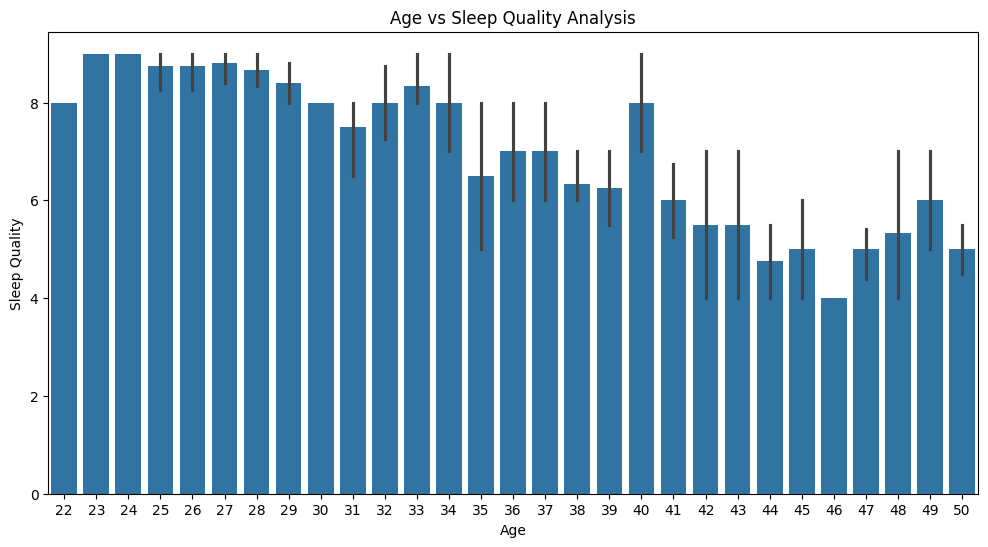

In [86]:
plt.figure(figsize=(12,6))
sns.barplot(x='Age',y='Sleep Quality',data=df)
plt.title("Age vs Sleep Quality Analysis")
plt.xlabel("Age")
plt.ylabel("Sleep Quality")
plt.show()

In [87]:
from sklearn.linear_model import LinearRegression
age_sleep_qual_model=LinearRegression()
x=df[['Age']]
y=df['Sleep Quality']
age_sleep_qual_model.fit(x,y)


LinearRegression()

In [88]:
age_sleep_qual_model.intercept_

np.float64(13.268812023190648)

In [89]:
age_sleep_qual_model.coef_

array([-0.17408531])

In [90]:
age_sleep_qual_predict=age_sleep_qual_model.predict(x)

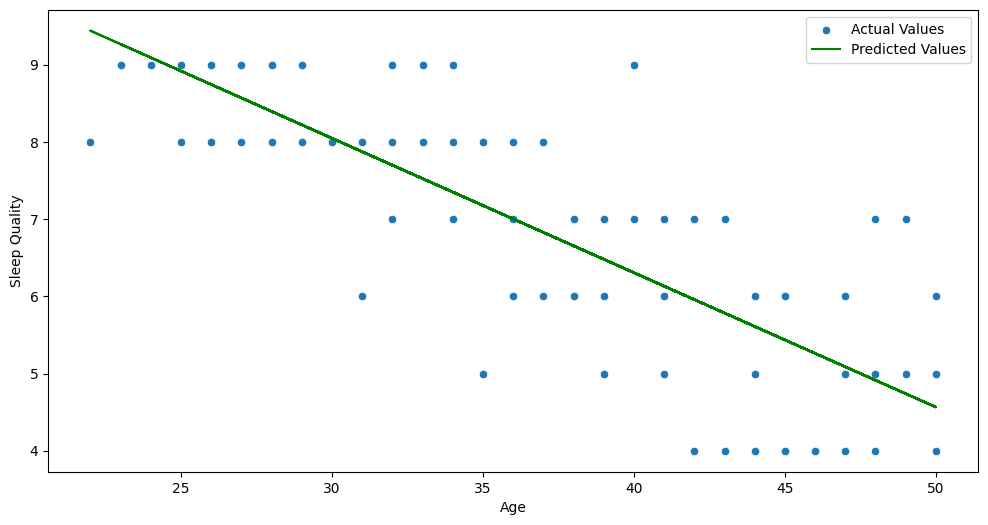

In [91]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Age',y='Sleep Quality',data=df,label='Actual Values')
plt.plot(x,age_sleep_qual_predict,color='green',label='Predicted Values')
plt.legend()
plt.show()


##Physical Activity vs Sleep Quality

<Axes: xlabel='Gender', ylabel='Sleep Quality'>

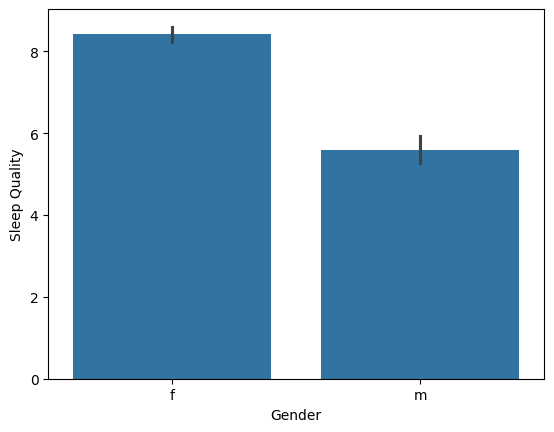

In [92]:
sns.barplot(x='Gender',y='Sleep Quality',data=df)

<Axes: xlabel='Physical Activity Level', ylabel='Sleep Quality'>

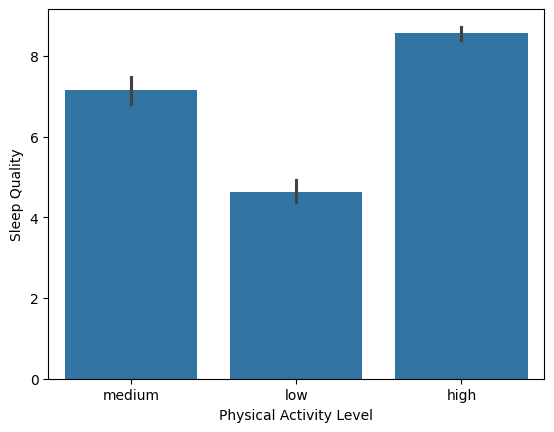

In [93]:
sns.barplot(x='Physical Activity Level',y='Sleep Quality',data=df)

In [94]:
custom_code={'low':1,'medium':2,'high':3}
df['Physical Activity Level']=df['Physical Activity Level'].map(custom_code)
df['Physical Activity Level'].head()

,Physical Activity Level
0,2
1,1
2,3
3,1
4,3


<Axes: xlabel='Gender', ylabel='Physical Activity Level'>

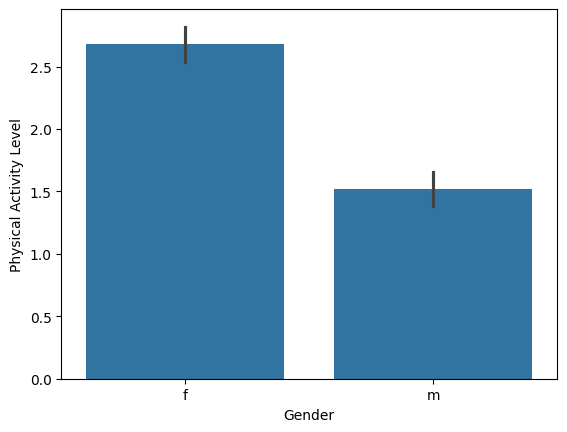

In [95]:
sns.barplot(x='Gender',y='Physical Activity Level',data=df)

In [96]:
from scipy import stats
sleep_qual_male=df[df['Gender']=='m']['Sleep Quality']
sleep_qual_female=df[df['Gender']=='f']['Sleep Quality']

physical_activity_male=df[df['Gender']=='m']['Physical Activity Level']
physical_activity_female=df[df['Gender']=='f']['Physical Activity Level']


###lets find t and p values for sleepquality vs Gender & sleepquality vs physical activity level

In [97]:
t_sleep_quality,p_sleep_quality=stats.ttest_ind(sleep_qual_male,sleep_qual_female)
print(f"t_ststs value for sleep quality vs Gender: {t_sleep_quality:.2f}")
print(f"p_ststs value for sleep quality vs Gender: {p_sleep_quality:.2f}")

t_ststs value for sleep quality vs Gender: -14.32
p_ststs value for sleep quality vs Gender: 0.00


In [98]:
t_physical_activity,p_physical_activity=stats.ttest_ind(physical_activity_male,physical_activity_female)

print(f"t_stats for physical activity vs Gender: {t_physical_activity:.2f}")
print(f"p_stats for physical activity vs Gender: {p_physical_activity:.2f}")

t_stats for physical activity vs Gender: -10.98
p_stats for physical activity vs Gender: 0.00


##Time of Sleep & Waking up vs Sleep Quality

In [99]:
df['Bedtime'].head()

,Bedtime
0,23:00
1,00:30
2,22:45
3,01:00
4,23:30


In [100]:
df['Wake-up Time'].head()

,Wake-up Time
0,06:30
1,07:00
2,06:45
3,06:30
4,07:00


In [101]:
def sleep_time_str_to_int(str_t):
  h=str_t.split(":")[0]
  m=str_t.split(":")[1]
  return int(h) + int(m)/60
df['Bedtime']=df['Bedtime'].apply(sleep_time_str_to_int)
df['Wake-up Time']=df['Wake-up Time'].apply(sleep_time_str_to_int)


In [102]:
df['Bedtime'].head()

,Bedtime
0,23.00
1,0.50
2,22.75
3,1.00
4,23.50


In [103]:
df['Wake-up Time'].head()

,Wake-up Time
0,6.50
1,7.00
2,6.75
3,6.50
4,7.00


In [104]:
df['sleep duration hours']=(df['Wake-up Time']-df['Bedtime'])%24

In [105]:
df['sleep duration hours'].head()

,sleep duration hours
0,7.5
1,6.5
2,8.0
3,5.5
4,7.5


In [106]:
df.head()

,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage,sleep duration hours
0,25,f,8,23.00,6.50,8000,2500,2,healthy,no,no,7.5
1,34,m,7,0.50,7.00,5000,2200,1,unhealthy,yes,yes,6.5
2,29,f,9,22.75,6.75,9000,2700,3,healthy,no,no,8.0
3,41,m,5,1.00,6.50,4000,2100,1,unhealthy,yes,no,5.5
4,22,f,8,23.50,7.00,10000,2800,3,medium,no,no,7.5


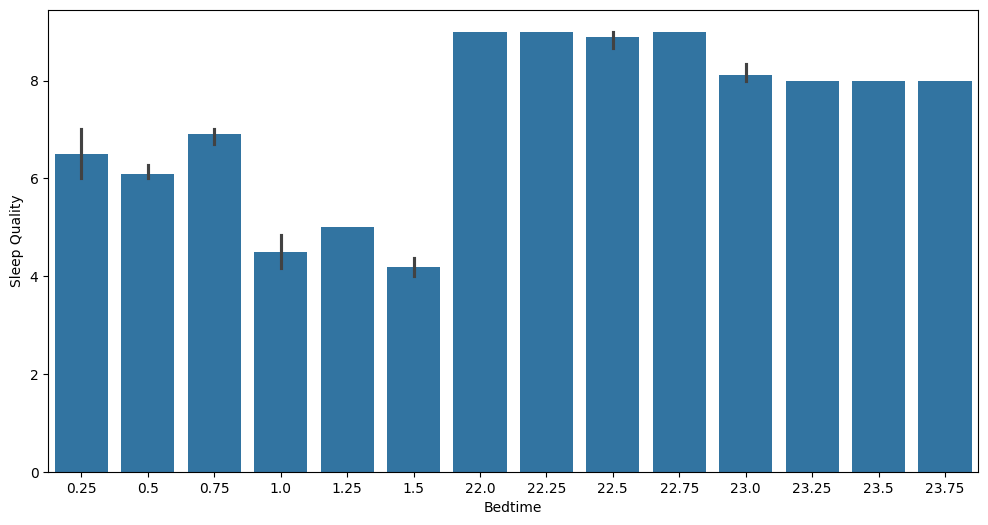

In [110]:
plt.figure(figsize=(12,6))
sns.barplot(x='Bedtime',y='Sleep Quality',data=df)
plt.show()

<Axes: xlabel='Wake-up Time', ylabel='Sleep Quality'>

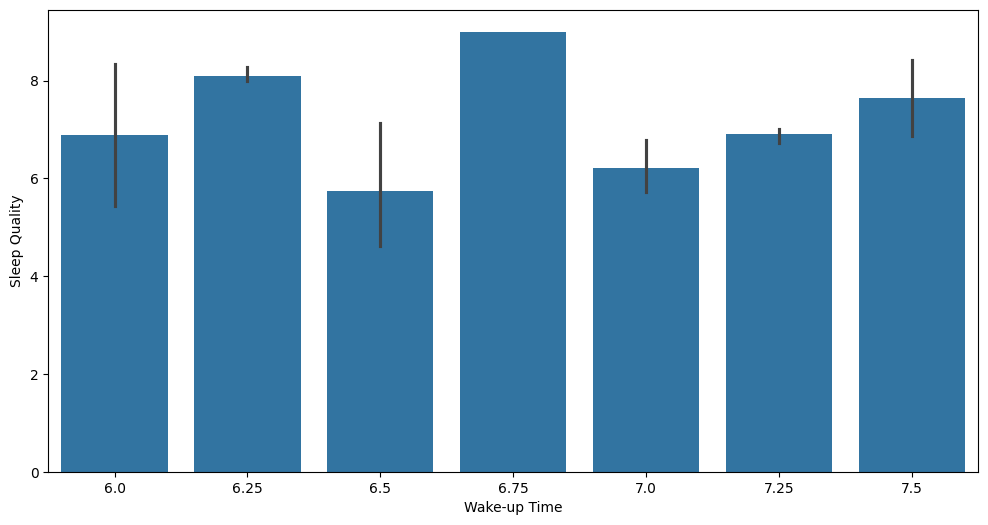

In [112]:
plt.figure(figsize=(12,6))
sns.barplot(x='Wake-up Time',y='Sleep Quality',data=df)

<Axes: xlabel='sleep duration hours', ylabel='Sleep Quality'>

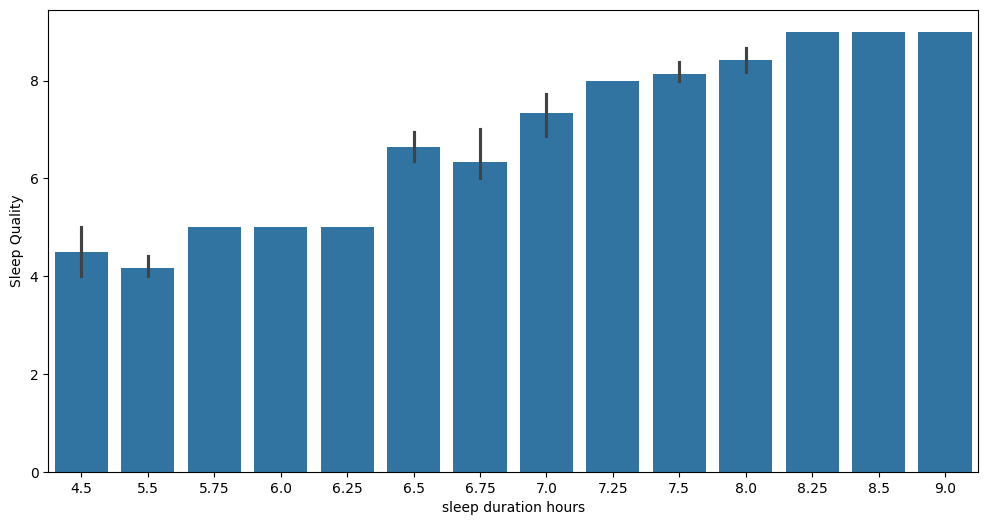

In [113]:
plt.figure(figsize=(12,6))
sns.barplot(x='sleep duration hours',y='Sleep Quality',data=df)

In [118]:
sleep_duration_qual_model=LinearRegression()
x=df[['sleep duration hours']]
y=df['Sleep Quality']
sleep_duration_qual_model.fit(x,y)

LinearRegression()

In [120]:
sleep_duration_qual_model.coef_

array([1.36940999])

In [121]:
sleep_duration_qual_model.intercept_

np.float64(-2.575599349763152)

In [128]:
predictions=sleep_duration_qual_model.predict(x)

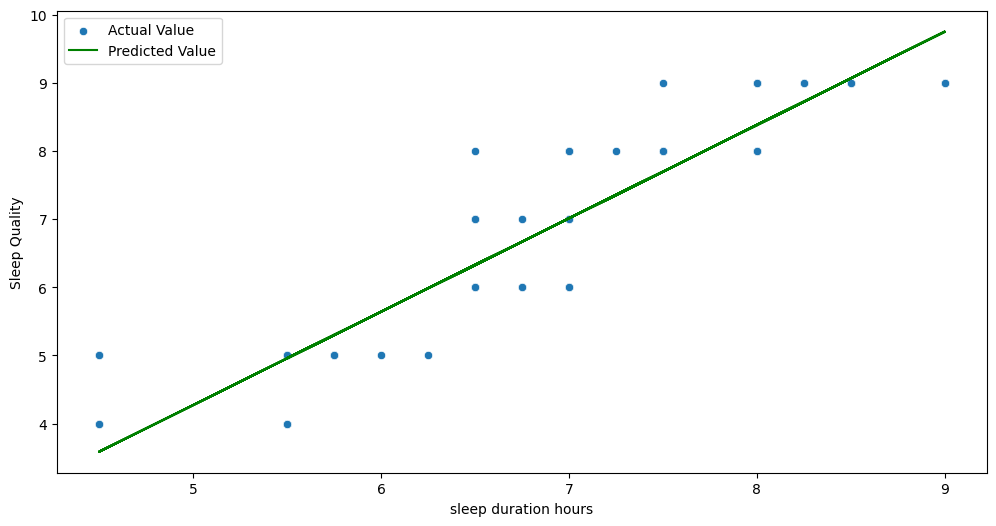

In [129]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='sleep duration hours',y='Sleep Quality',data=df,label='Actual Value')
plt.plot(x,predictions,color='green',label='Predicted Value')
plt.legend()
plt.show()

In [130]:
df.head()

,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage,sleep duration hours
0,25,f,8,23.00,6.50,8000,2500,2,healthy,no,no,7.5
1,34,m,7,0.50,7.00,5000,2200,1,unhealthy,yes,yes,6.5
2,29,f,9,22.75,6.75,9000,2700,3,healthy,no,no,8.0
3,41,m,5,1.00,6.50,4000,2100,1,unhealthy,yes,no,5.5
4,22,f,8,23.50,7.00,10000,2800,3,medium,no,no,7.5


##**Sleep Disorders** vs **Sleep Qualit**

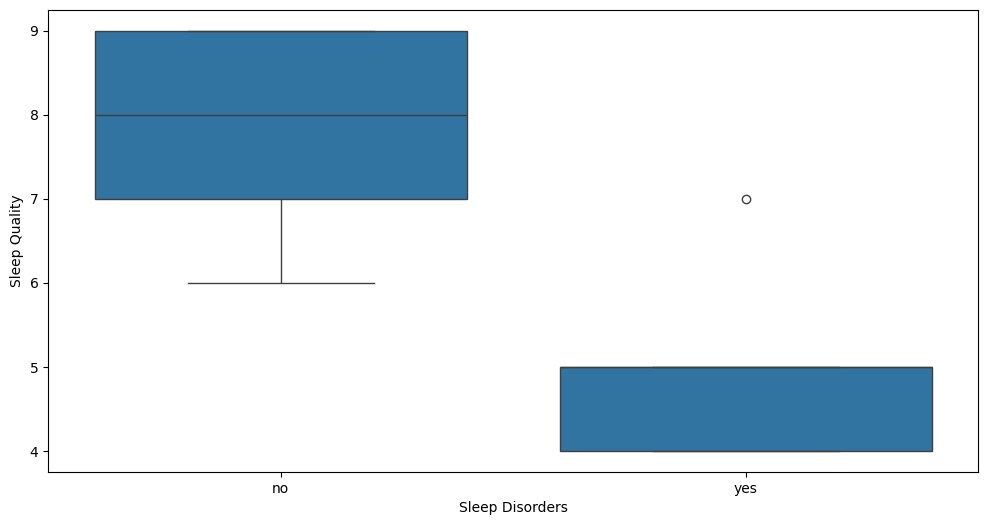

In [133]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Sleep Disorders',y='Sleep Quality',data=df)
plt.show()

In [135]:
df_numeric_values=df.select_dtypes(include=['int64','float64'])
df_numeric_values.head()

,Age,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,sleep duration hours
0,25,8,23.00,6.50,8000,2500,2,7.5
1,34,7,0.50,7.00,5000,2200,1,6.5
2,29,9,22.75,6.75,9000,2700,3,8.0
3,41,5,1.00,6.50,4000,2100,1,5.5
4,22,8,23.50,7.00,10000,2800,3,7.5


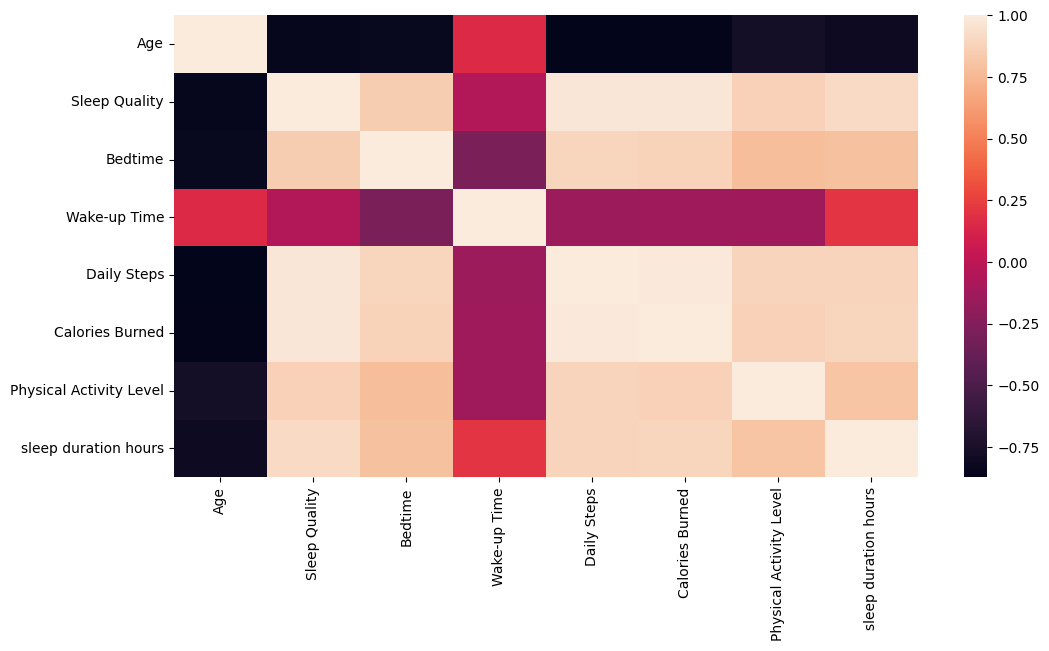

In [136]:
plt.figure(figsize=(12,6))
sns.heatmap(df_numeric_values.corr())
plt.show()